In [420]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [421]:
# Project paths

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data directory:")
print(PROCESSED_DIR)

Project root:
C:\Users\Aditya\Smart_traffic_management

Processed data directory:
C:\Users\Aditya\Smart_traffic_management\data\processed


In [422]:
# Find processed CSV files

csv_files = sorted(PROCESSED_DIR.glob("*.csv"))

print(f"Number of CSV files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Number of CSV files found: 1
traffic_2025.csv


In [423]:
# Select the processed dataset

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {PROCESSED_DIR}"
    )

DATA_PATH = csv_files[0]

print("Selected dataset:")
print(DATA_PATH)

Selected dataset:
C:\Users\Aditya\Smart_traffic_management\data\processed\traffic_2025.csv


In [424]:
# Load a working sample

SAMPLE_SIZE = 10_000

df = pd.read_csv(
    DATA_PATH,
    nrows=SAMPLE_SIZE
)

print("Dataset loaded.")
print("Shape:", df.shape)

Dataset loaded.
Shape: (10000, 103)


In [425]:
# Inspect QT_INTERVAL_COUNT

print(df["QT_INTERVAL_COUNT"].head(10))

print("\nData type:")
print(df["QT_INTERVAL_COUNT"].dtype)

0    2025-04-01
1    2025-04-01
2    2025-04-01
3    2025-04-01
4    2025-04-01
5    2025-04-01
6    2025-04-01
7    2025-04-01
8    2025-04-01
9    2025-04-01
Name: QT_INTERVAL_COUNT, dtype: str

Data type:
str


In [426]:
# Convert QT_INTERVAL_COUNT to datetime

df["QT_INTERVAL_COUNT"] = pd.to_datetime(
    df["QT_INTERVAL_COUNT"],
    errors="coerce"
)

print("Data type after conversion:")
print(df["QT_INTERVAL_COUNT"].dtype)

print("\nMissing datetime values:")
print(df["QT_INTERVAL_COUNT"].isna().sum())

Data type after conversion:
datetime64[us]

Missing datetime values:
0


In [427]:
# Check date range

print("Minimum date:")
print(df["QT_INTERVAL_COUNT"].min())

print("\nMaximum date:")
print(df["QT_INTERVAL_COUNT"].max())

print("\nNumber of unique dates:")
print(df["QT_INTERVAL_COUNT"].nunique())

Minimum date:
2025-04-01 00:00:00

Maximum date:
2025-04-01 00:00:00

Number of unique dates:
1


In [428]:
# Inspect converted datetime values

display(
    df[
        ["QT_INTERVAL_COUNT"]
    ].head(20)
)

,QT_INTERVAL_COUNT
0,2025-04-01
1,2025-04-01
2,2025-04-01
3,2025-04-01
4,2025-04-01
5,2025-04-01
6,2025-04-01
7,2025-04-01
8,2025-04-01
9,2025-04-01


In [429]:
# Identify traffic interval columns

traffic_columns = [
    column
    for column in df.columns
    if (
        isinstance(column, str)
        and column.startswith("V")
        and column[1:].isdigit()
    )
]

# Sort them numerically: V00, V01, ..., V95
traffic_columns = sorted(
    traffic_columns,
    key=lambda x: int(x[1:])
)

print("Number of traffic interval columns:")
print(len(traffic_columns))

print("\nTraffic interval columns:")
print(traffic_columns)

Number of traffic interval columns:
96

Traffic interval columns:
['V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95']


In [430]:
# Verify V-column sequence

expected_columns = [
    f"V{i:02d}"
    for i in range(96)
]

missing_intervals = [
    column
    for column in expected_columns
    if column not in traffic_columns
]

unexpected_intervals = [
    column
    for column in traffic_columns
    if column not in expected_columns
]

print("Missing expected intervals:")
print(missing_intervals)

print("\nUnexpected interval columns:")
print(unexpected_intervals)

Missing expected intervals:
[]

Unexpected interval columns:
[]


In [431]:
# Validate 96 × 15-minute structure

number_of_intervals = len(traffic_columns)
minutes_per_interval = 15

total_minutes = (
    number_of_intervals
    * minutes_per_interval
)

total_hours = total_minutes / 60

print("Number of intervals:", number_of_intervals)
print("Minutes per interval:", minutes_per_interval)
print("Total minutes:", total_minutes)
print("Total hours:", total_hours)

print(
    "\nCovers exactly 24 hours:",
    total_minutes == 24 * 60
)

Number of intervals: 96
Minutes per interval: 15
Total minutes: 1440
Total hours: 24.0

Covers exactly 24 hours: True


In [432]:
# Create interval-to-time mapping

interval_mapping = pd.DataFrame({
    "interval": traffic_columns,
    "interval_index": range(len(traffic_columns))
})

interval_mapping["start_minutes"] = (
    interval_mapping["interval_index"] * 15
)

interval_mapping["start_time"] = pd.to_timedelta(
    interval_mapping["start_minutes"],
    unit="m"
)

display(interval_mapping)

,interval,interval_index,start_minutes,start_time
0,V00,0,0,0 days 00:00:00
1,V01,1,15,0 days 00:15:00
2,V02,2,30,0 days 00:30:00
3,V03,3,45,0 days 00:45:00
4,V04,4,60,0 days 01:00:00
...,...,...,...,...
91,V91,91,1365,0 days 22:45:00
92,V92,92,1380,0 days 23:00:00
93,V93,93,1395,0 days 23:15:00
94,V94,94,1410,0 days 23:30:00


In [433]:
# Check first and last intervals

print("First intervals:")
display(interval_mapping.head(10))

print("\nLast intervals:")
display(interval_mapping.tail(10))

First intervals:


,interval,interval_index,start_minutes,start_time
0,V00,0,0,0 days 00:00:00
1,V01,1,15,0 days 00:15:00
2,V02,2,30,0 days 00:30:00
3,V03,3,45,0 days 00:45:00
4,V04,4,60,0 days 01:00:00
5,V05,5,75,0 days 01:15:00
6,V06,6,90,0 days 01:30:00
7,V07,7,105,0 days 01:45:00
8,V08,8,120,0 days 02:00:00
9,V09,9,135,0 days 02:15:00



Last intervals:


,interval,interval_index,start_minutes,start_time
86,V86,86,1290,0 days 21:30:00
87,V87,87,1305,0 days 21:45:00
88,V88,88,1320,0 days 22:00:00
89,V89,89,1335,0 days 22:15:00
90,V90,90,1350,0 days 22:30:00
91,V91,91,1365,0 days 22:45:00
92,V92,92,1380,0 days 23:00:00
93,V93,93,1395,0 days 23:15:00
94,V94,94,1410,0 days 23:30:00
95,V95,95,1425,0 days 23:45:00


In [434]:
# Check the basic row structure

print("Unique SCATS sites:")
print(df["NB_SCATS_SITE"].nunique())

print("\nUnique detector IDs:")
print(df["NB_DETECTOR"].nunique())

print("\nUnique dates:")
print(df["QT_INTERVAL_COUNT"].nunique())

Unique SCATS sites:
396

Unique detector IDs:
32

Unique dates:
1


In [435]:
# Check SCATS site and detector combinations

site_detector = (
    df[
        ["NB_SCATS_SITE", "NB_DETECTOR"]
    ]
    .drop_duplicates()
)

print(
    "Unique site-detector combinations:",
    len(site_detector)
)

display(
    site_detector.head(20)
)

Unique site-detector combinations: 10000


,NB_SCATS_SITE,NB_DETECTOR
0,100,1
1,100,2
2,100,3
3,100,4
4,100,5
5,100,6
6,100,7
7,100,8
8,100,9
9,100,10


In [436]:
# Number of detectors at each SCATS site

detectors_per_site = (
    df.groupby("NB_SCATS_SITE")["NB_DETECTOR"]
    .nunique()
    .sort_values(ascending=False)
)

print("Detector count per site:")

display(
    detectors_per_site.describe()
)

print("\nSites with the most detectors:")

display(
    detectors_per_site.head(20)
)

Detector count per site:


count    396.000000
mean      25.252525
std        2.965945
min       16.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       32.000000
Name: NB_DETECTOR, dtype: float64


Sites with the most detectors:


NB_SCATS_SITE
157    32
166    32
138    32
222    32
223    32
169    32
107    32
142    32
143    32
307    32
510    32
263    32
248    32
147    32
148    32
280    32
195    32
196    32
519    32
265    32
Name: NB_DETECTOR, dtype: int64

In [437]:
# Check the detector limit

max_detectors = detectors_per_site.max()

print(
    "Maximum number of detectors observed at one site:",
    max_detectors
)

print(
    "\nSites exceeding 24 detectors:",
    (detectors_per_site > 24).sum()
)

Maximum number of detectors observed at one site: 32

Sites exceeding 24 detectors: 63


In [438]:
# Check whether one row represents one site-detector-day

row_key = [
    "NB_SCATS_SITE",
    "NB_DETECTOR",
    "QT_INTERVAL_COUNT"
]

duplicate_key_count = df.duplicated(
    subset=row_key,
    keep=False
).sum()

print(
    "Rows involved in duplicate site-detector-date keys:",
    duplicate_key_count
)

print(
    "Total rows:",
    len(df)
)

print(
    "Key is unique:",
    duplicate_key_count == 0
)

Rows involved in duplicate site-detector-date keys: 0
Total rows: 10000
Key is unique: True


In [439]:
# Inspect one detector-day record

example_row = df.iloc[0]

print("SCATS site:")
print(example_row["NB_SCATS_SITE"])

print("\nDetector:")
print(example_row["NB_DETECTOR"])

print("\nDate:")
print(example_row["QT_INTERVAL_COUNT"])

print("\nFirst 10 traffic intervals:")

display(
    example_row[
        traffic_columns[:10]
    ]
)

SCATS site:
100

Detector:
1

Date:
2025-04-01 00:00:00

First 10 traffic intervals:


V00    2
V01    1
V02    1
V03    2
V04    4
V05    1
V06    4
V07    0
V08    1
V09    1
Name: 0, dtype: object

In [440]:
# Complete 24-hour traffic profile for one detector-day

daily_profile = (
    example_row[
        traffic_columns
    ]
    .astype(float)
)

profile_df = pd.DataFrame({
    "interval": traffic_columns,
    "volume": daily_profile.values
})

profile_df = profile_df.merge(
    interval_mapping[
        [
            "interval",
            "interval_index",
            "start_time"
        ]
    ],
    on="interval",
    how="left"
)

display(profile_df)

,interval,volume,interval_index,start_time
0,V00,2.0,0,0 days 00:00:00
1,V01,1.0,1,0 days 00:15:00
2,V02,1.0,2,0 days 00:30:00
3,V03,2.0,3,0 days 00:45:00
4,V04,4.0,4,0 days 01:00:00
...,...,...,...,...
91,V91,9.0,91,0 days 22:45:00
92,V92,4.0,92,0 days 23:00:00
93,V93,7.0,93,0 days 23:15:00
94,V94,3.0,94,0 days 23:30:00


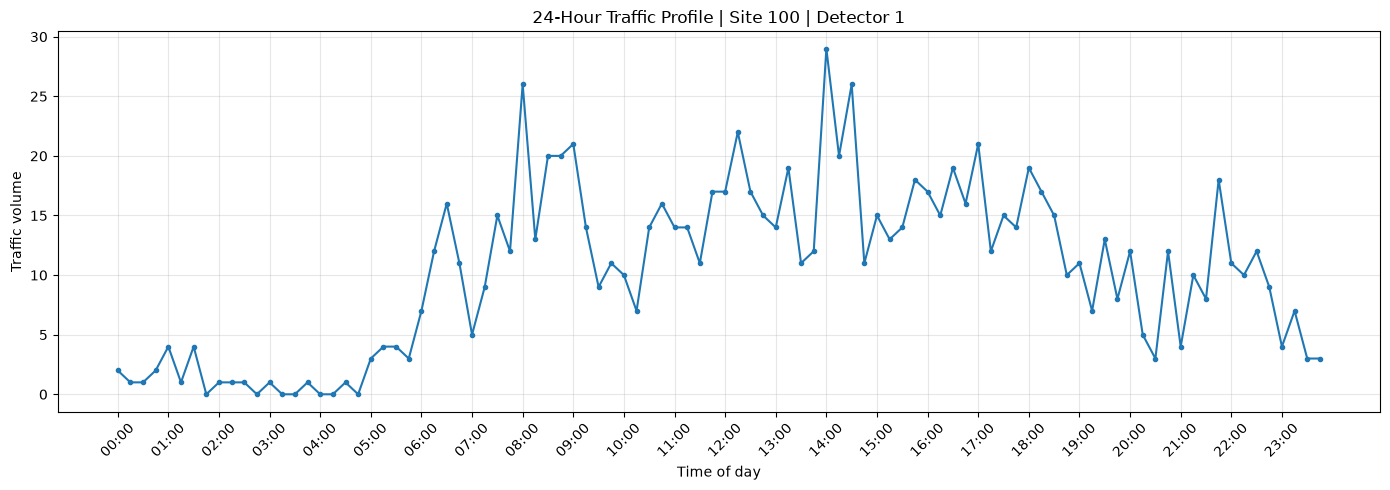

In [441]:
# Plot one detector-day traffic profile

# Select the first available site and detector
example_site = df["NB_SCATS_SITE"].iloc[0]
example_detector = df["NB_DETECTOR"].iloc[0]

# Select that site-detector combination
example_rows = df[
    (df["NB_SCATS_SITE"] == example_site) &
    (df["NB_DETECTOR"] == example_detector)
]

# Take the first available day
example_row = example_rows.iloc[0]

# Extract the 96 traffic values
daily_profile = (
    example_row[traffic_columns]
    .astype(float)
)

# Create a DataFrame for plotting
profile_df = pd.DataFrame({
    "interval": traffic_columns,
    "volume": daily_profile.values
})

# Add interval index
profile_df["interval_index"] = range(
    len(profile_df)
)

# Add time information
profile_df["start_time"] = pd.to_timedelta(
    profile_df["interval_index"] * 15,
    unit="m"
)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(
    profile_df["interval_index"],
    profile_df["volume"],
    marker="o",
    markersize=3
)

plt.xlabel("Time of day")
plt.ylabel("Traffic volume")

plt.title(
    f"24-Hour Traffic Profile | "
    f"Site {example_site} | "
    f"Detector {example_detector}"
)

plt.xticks(
    range(0, 96, 4),
    [
        f"{hour:02d}:00"
        for hour in range(24)
    ],
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [442]:
# Find the busiest 15-minute intervals

peak_intervals = (
    profile_df
    .sort_values(
        "volume",
        ascending=False
    )
    .head(10)
)

display(
    peak_intervals[
        [
            "interval",
            "interval_index",
            "start_time",
            "volume"
        ]
    ]
)

,interval,interval_index,start_time,volume
56,V56,56,0 days 14:00:00,29.0
32,V32,32,0 days 08:00:00,26.0
58,V58,58,0 days 14:30:00,26.0
49,V49,49,0 days 12:15:00,22.0
68,V68,68,0 days 17:00:00,21.0
36,V36,36,0 days 09:00:00,21.0
57,V57,57,0 days 14:15:00,20.0
35,V35,35,0 days 08:45:00,20.0
34,V34,34,0 days 08:30:00,20.0
72,V72,72,0 days 18:00:00,19.0


In [443]:
# Find intervals with zero traffic

zero_intervals = profile_df[
    profile_df["volume"] == 0
]

print(
    "Number of zero-volume intervals:",
    len(zero_intervals)
)

display(
    zero_intervals[
        [
            "interval",
            "interval_index",
            "start_time",
            "volume"
        ]
    ]
)

Number of zero-volume intervals: 7


,interval,interval_index,start_time,volume
7,V07,7,0 days 01:45:00,0.0
11,V11,11,0 days 02:45:00,0.0
13,V13,13,0 days 03:15:00,0.0
14,V14,14,0 days 03:30:00,0.0
16,V16,16,0 days 04:00:00,0.0
17,V17,17,0 days 04:15:00,0.0
19,V19,19,0 days 04:45:00,0.0


In [444]:
# Compare zero traffic with CT_RECORDS

print("CT_RECORDS:")
print(example_row["CT_RECORDS"])

print("\nNumber of V intervals:")
print(len(traffic_columns))

print("\nZero-volume intervals:")
print(len(zero_intervals))

print("\nNon-zero intervals:")
print(
    (profile_df["volume"] != 0).sum()
)

CT_RECORDS:
96

Number of V intervals:
96

Zero-volume intervals:
7

Non-zero intervals:
89


In [445]:
# Average traffic volume at each 15-minute interval

interval_means = df[traffic_columns].mean()

display(
    interval_means.to_frame(
        name="mean_volume"
    )
)

,mean_volume
V00,3.1192
V01,2.7293
V02,2.4578
V03,2.2024
V04,1.9577
...,...
V91,5.7018
V92,5.1239
V93,4.3160
V94,3.6170


In [446]:
# Combine average traffic with time information

average_profile = interval_mapping[
    [
        "interval",
        "interval_index",
        "start_time"
    ]
].copy()

average_profile["mean_volume"] = (
    average_profile["interval"]
    .map(interval_means)
)

display(average_profile)

,interval,interval_index,start_time,mean_volume
0,V00,0,0 days 00:00:00,3.1192
1,V01,1,0 days 00:15:00,2.7293
2,V02,2,0 days 00:30:00,2.4578
3,V03,3,0 days 00:45:00,2.2024
4,V04,4,0 days 01:00:00,1.9577
...,...,...,...,...
91,V91,91,0 days 22:45:00,5.7018
92,V92,92,0 days 23:00:00,5.1239
93,V93,93,0 days 23:15:00,4.3160
94,V94,94,0 days 23:30:00,3.6170


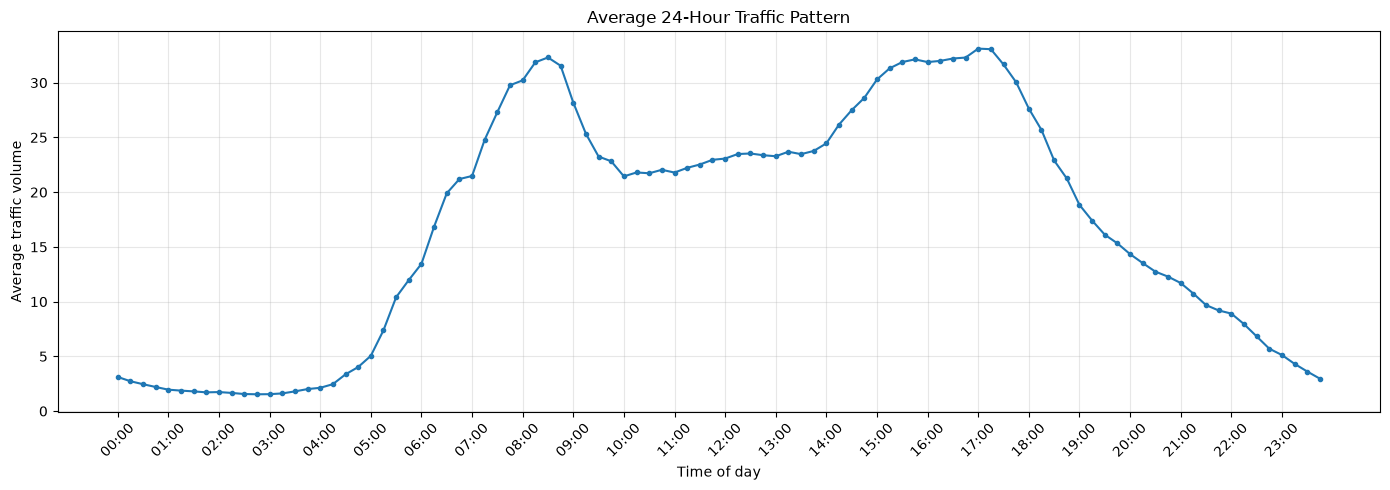

In [447]:
# Average traffic pattern across the day

plt.figure(figsize=(14, 5))

plt.plot(
    average_profile["interval_index"],
    average_profile["mean_volume"],
    marker="o",
    markersize=3
)

plt.xlabel("Time of day")
plt.ylabel("Average traffic volume")
plt.title("Average 24-Hour Traffic Pattern")

plt.xticks(
    range(0, 96, 4),
    [
        f"{hour:02d}:00"
        for hour in range(24)
    ],
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [448]:
# Identify the busiest intervals in the average profile

busiest_intervals = (
    average_profile
    .sort_values(
        "mean_volume",
        ascending=False
    )
    .head(10)
)

display(
    busiest_intervals[
        [
            "interval",
            "start_time",
            "mean_volume"
        ]
    ]
)

,interval,start_time,mean_volume
68,V68,0 days 17:00:00,33.1144
69,V69,0 days 17:15:00,33.0617
34,V34,0 days 08:30:00,32.3056
67,V67,0 days 16:45:00,32.2963
66,V66,0 days 16:30:00,32.2103
63,V63,0 days 15:45:00,32.1319
65,V65,0 days 16:15:00,31.9929
62,V62,0 days 15:30:00,31.8864
64,V64,0 days 16:00:00,31.8861
33,V33,0 days 08:15:00,31.8636


In [449]:
# Identify the quietest intervals

quietest_intervals = (
    average_profile
    .sort_values(
        "mean_volume",
        ascending=True
    )
    .head(10)
)

display(
    quietest_intervals[
        [
            "interval",
            "start_time",
            "mean_volume"
        ]
    ]
)

,interval,start_time,mean_volume
11,V11,0 days 02:45:00,1.5361
12,V12,0 days 03:00:00,1.5467
10,V10,0 days 02:30:00,1.5597
13,V13,0 days 03:15:00,1.6155
9,V09,0 days 02:15:00,1.6617
7,V07,0 days 01:45:00,1.7132
8,V08,0 days 02:00:00,1.7388
14,V14,0 days 03:30:00,1.8006
6,V06,0 days 01:30:00,1.8014
5,V05,0 days 01:15:00,1.8720


In [450]:
# Zero-volume percentage for each 15-minute interval

zero_percentage = (
    (df[traffic_columns] == 0)
    .mean()
    * 100
)

zero_percentage = zero_percentage.sort_values(
    ascending=False
)

display(
    zero_percentage.to_frame(
        name="zero_percentage"
    )
)

,zero_percentage
V11,75.44
V12,74.43
V10,74.34
V09,74.31
V08,73.93
...,...
V65,54.37
V35,54.35
V61,54.29
V63,54.29


In [451]:
# Combine zero percentage with interval timing

zero_profile = interval_mapping[
    [
        "interval",
        "interval_index",
        "start_time"
    ]
].copy()

zero_profile["zero_percentage"] = (
    zero_profile["interval"]
    .map(zero_percentage)
)

display(zero_profile)

,interval,interval_index,start_time,zero_percentage
0,V00,0,0 days 00:00:00,64.79
1,V01,1,0 days 00:15:00,66.64
2,V02,2,0 days 00:30:00,67.94
3,V03,3,0 days 00:45:00,69.03
4,V04,4,0 days 01:00:00,70.06
...,...,...,...,...
91,V91,91,0 days 22:45:00,60.12
92,V92,92,0 days 23:00:00,60.75
93,V93,93,0 days 23:15:00,62.18
94,V94,94,0 days 23:30:00,63.28


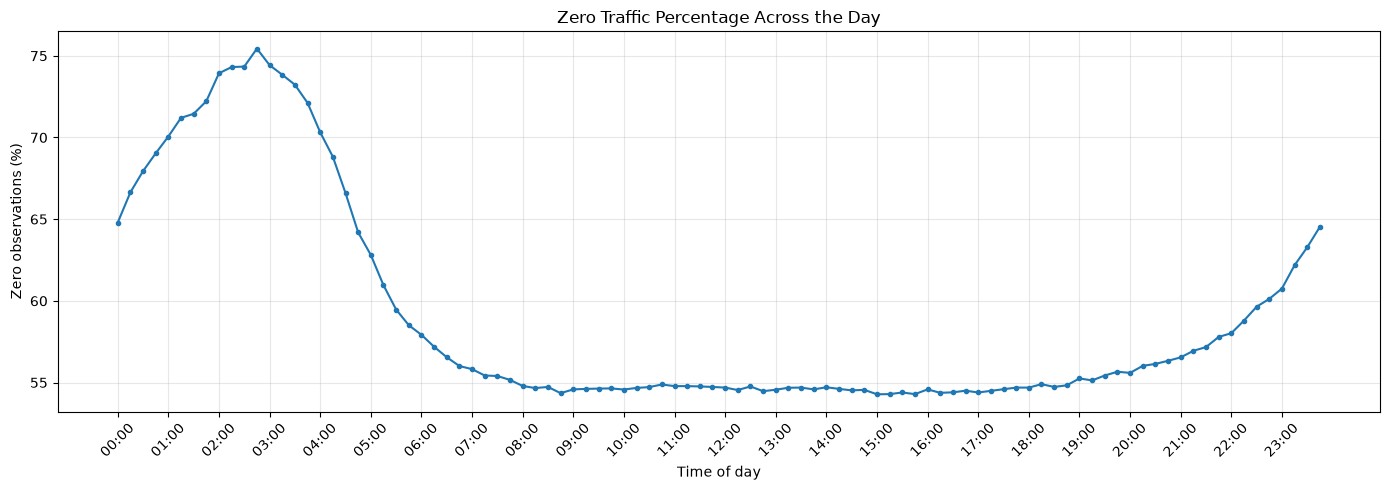

In [452]:
# Zero-volume pattern across the day

plt.figure(figsize=(14, 5))

plt.plot(
    zero_profile["interval_index"],
    zero_profile["zero_percentage"],
    marker="o",
    markersize=3
)

plt.xlabel("Time of day")
plt.ylabel("Zero observations (%)")
plt.title("Zero Traffic Percentage Across the Day")

plt.xticks(
    range(0, 96, 4),
    [
        f"{hour:02d}:00"
        for hour in range(24)
    ],
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [453]:
# Zero-volume percentage for each SCATS site

site_zero_rate = (
    df.groupby("NB_SCATS_SITE")[traffic_columns]
    .apply(lambda x: (x == 0).mean().mean() * 100)
    .sort_values(ascending=False)
)

display(
    site_zero_rate.to_frame(
        name="zero_percentage"
    ).head(20)
)

,zero_percentage
NB_SCATS_SITE,
470,100.000000
468,100.000000
486,100.000000
485,100.000000
484,100.000000
462,100.000000
475,100.000000
471,100.000000
477,100.000000


In [454]:
# Distribution of zero-volume rates across SCATS sites

site_zero_rate.describe()

count    396.000000
mean      59.066194
std       21.445090
min        0.000000
25%       45.323351
50%       59.505208
75%       73.863390
max      100.000000
dtype: float64

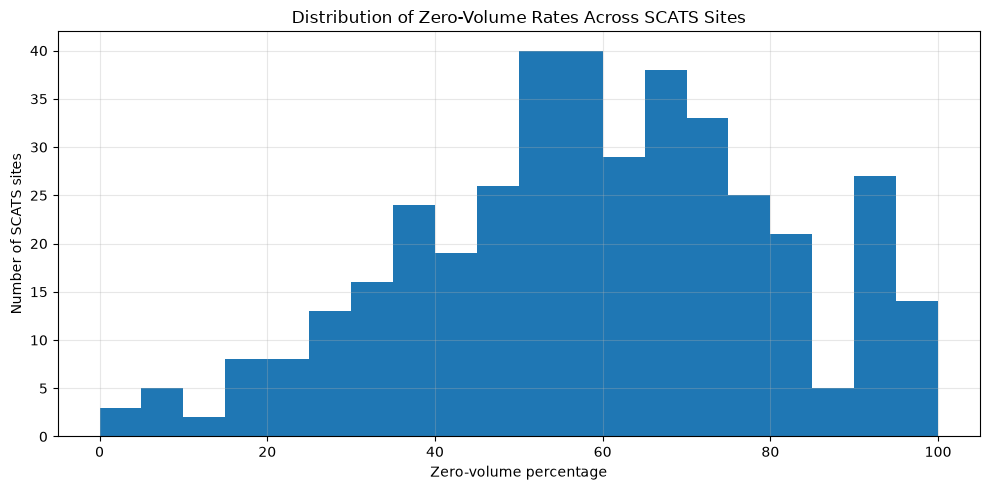

In [455]:
# Distribution of zero-volume percentages by site

plt.figure(figsize=(10, 5))

plt.hist(
    site_zero_rate,
    bins=20
)

plt.xlabel("Zero-volume percentage")
plt.ylabel("Number of SCATS sites")
plt.title("Distribution of Zero-Volume Rates Across SCATS Sites")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [456]:
# Zero-volume percentage for each detector

detector_zero_rate = (
    df.groupby("NB_DETECTOR")[traffic_columns]
    .apply(lambda x: (x == 0).mean().mean() * 100)
    .sort_values(ascending=False)
)

display(
    detector_zero_rate.to_frame(
        name="zero_percentage"
    )
)

,zero_percentage
NB_DETECTOR,
0,99.553571
30,99.189815
31,98.296958
29,98.148148
27,95.585317
24,94.549051
26,94.494048
28,94.080688
23,92.840190


In [457]:
# Distribution of zero-volume rates across detectors

detector_zero_rate.describe()

count    32.000000
mean     66.954313
std      30.062625
min      15.506629
25%      38.258233
50%      79.468738
75%      93.150314
max      99.553571
dtype: float64

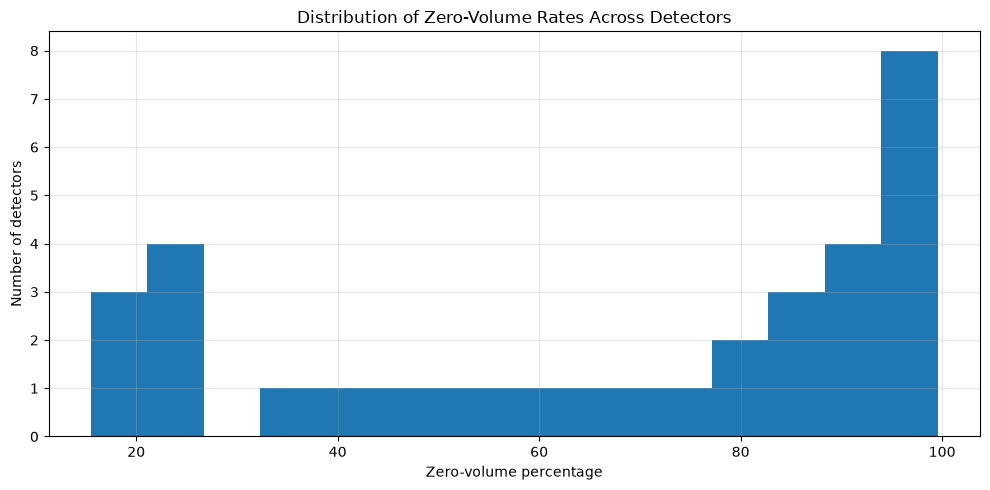

In [458]:
# Distribution of zero-volume percentages by detector

plt.figure(figsize=(10, 5))

plt.hist(
    detector_zero_rate,
    bins=15
)

plt.xlabel("Zero-volume percentage")
plt.ylabel("Number of detectors")
plt.title("Distribution of Zero-Volume Rates Across Detectors")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [459]:
# Zero-volume percentage for each site-detector combination

site_detector_zero_rate = (
    df.groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )[traffic_columns]
    .apply(lambda x: (x == 0).mean().mean() * 100)
    .sort_values(ascending=False)
)

display(
    site_detector_zero_rate
    .to_frame(
        name="zero_percentage"
    )
    .head(20)
)

zero_percentage
NB_SCATS_SITE NB_DETECTOR                 
547           24                     100.0
              23                     100.0
              22                     100.0
              21                     100.0
              20                     100.0
              19                     100.0
              18                     100.0
              17                     100.0
              16                     100.0
              15                     100.0
              14                     100.0
              13                     100.0
              12                     100.0
              11                     100.0
              10                     100.0
100           24                     100.0
              23                     100.0
              22                     100.0
              21                     100.0
              20                     100.0

In [460]:
# Count observations for each site-detector combination

site_detector_counts = (
    df.groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )
    .size()
    .sort_values(ascending=False)
)

display(
    site_detector_counts.describe()
)

count    10000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

In [461]:
# Site-detector combinations with 100% zero traffic

fully_zero_pairs = (
    site_detector_zero_rate[
        site_detector_zero_rate == 100
    ]
)

print(
    "Number of site-detector pairs with 100% zero traffic:",
    len(fully_zero_pairs)
)

display(
    fully_zero_pairs.head(30)
)

Number of site-detector pairs with 100% zero traffic: 5313


NB_SCATS_SITE  NB_DETECTOR
547            24             100.0
               23             100.0
               22             100.0
               21             100.0
               20             100.0
               19             100.0
               18             100.0
               17             100.0
               16             100.0
               15             100.0
               14             100.0
               13             100.0
               12             100.0
               11             100.0
               10             100.0
100            24             100.0
               23             100.0
               22             100.0
               21             100.0
               20             100.0
               19             100.0
               18             100.0
               17             100.0
101            24             100.0
               23             100.0
               22             100.0
               21             100.0
 

In [462]:
# Combine observation count and zero rate

site_detector_quality = pd.concat(
    [
        site_detector_counts.rename(
            "record_count"
        ),
        site_detector_zero_rate.rename(
            "zero_percentage"
        )
    ],
    axis=1
)

display(
    site_detector_quality
    .sort_values(
        "zero_percentage",
        ascending=False
    )
    .head(30)
)

record_count  zero_percentage
NB_SCATS_SITE NB_DETECTOR                               
547           24                      1            100.0
              23                      1            100.0
              22                      1            100.0
              21                      1            100.0
              20                      1            100.0
              19                      1            100.0
              18                      1            100.0
              17                      1            100.0
              16                      1            100.0
              15                      1            100.0
              14                      1            100.0
              13                      1            100.0
              12                      1            100.0
              11                      1            100.0
              10                      1            100.0
100           24                      1            100.0
              23                      1            100.0
              22                      1            100.0
              21                      1            100.0
              20                      1            100.0
              19                      1            100.0
              18                      1            100.0
              17                      1            100.0
101           24                      1            100.0
              23                      1            100.0
              22                      1            100.0
              21                      1            100.0
              20                      1            100.0
              19                      1            100.0
              18                      1            100.0

In [463]:
# Inspect one completely zero site-detector combination

if len(fully_zero_pairs) > 0:

    suspicious_site = fully_zero_pairs.index[0][0]
    suspicious_detector = fully_zero_pairs.index[0][1]

    suspicious_rows = df[
        (df["NB_SCATS_SITE"] == suspicious_site)
        &
        (df["NB_DETECTOR"] == suspicious_detector)
    ]

    print("SCATS site:", suspicious_site)
    print("Detector:", suspicious_detector)
    print("Number of rows:", len(suspicious_rows))

    display(
        suspicious_rows[
            [
                "NB_SCATS_SITE",
                "NB_DETECTOR",
                "QT_INTERVAL_COUNT",
                "CT_RECORDS",
                "QT_VOLUME_24HOUR"
            ]
        ]
        .head(20)
    )

SCATS site: 547
Detector: 24
Number of rows: 1


,NB_SCATS_SITE,NB_DETECTOR,QT_INTERVAL_COUNT,CT_RECORDS,QT_VOLUME_24HOUR
9983,547,24,2025-04-01,96,0


In [464]:
# Check date coverage using chunks

date_values = set()

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=["QT_INTERVAL_COUNT"],
    chunksize=100_000
):
    dates = pd.to_datetime(
        chunk["QT_INTERVAL_COUNT"],
        errors="coerce"
    ).dropna()

    date_values.update(
        dates.dt.date.unique()
    )

print(
    "Number of unique dates:",
    len(date_values)
)

print(
    "\nFirst 10 dates:"
)

for date in sorted(date_values)[:10]:
    print(date)

print(
    "\nLast 10 dates:"
)

for date in sorted(date_values)[-10:]:
    print(date)

Number of unique dates: 363

First 10 dates:
2025-01-01
2025-01-02
2025-01-03
2025-01-04
2025-01-05
2025-01-06
2025-01-07
2025-01-08
2025-01-09
2025-01-10

Last 10 dates:
2025-12-21
2025-12-22
2025-12-23
2025-12-24
2025-12-25
2025-12-26
2025-12-27
2025-12-28
2025-12-29
2025-12-30


In [465]:
# Load a larger sample for temporal analysis

TEMPORAL_SAMPLE_SIZE = 500_000

df_temporal = pd.read_csv(
    DATA_PATH,
    nrows=TEMPORAL_SAMPLE_SIZE
)

# Convert datetime column
df_temporal["QT_INTERVAL_COUNT"] = pd.to_datetime(
    df_temporal["QT_INTERVAL_COUNT"],
    errors="coerce"
)

print("Rows loaded:", len(df_temporal))

print(
    "Unique dates:",
    df_temporal["QT_INTERVAL_COUNT"].dt.date.nunique()
)

print(
    "Date range:",
    df_temporal["QT_INTERVAL_COUNT"].min(),
    "to",
    df_temporal["QT_INTERVAL_COUNT"].max()
)

Rows loaded: 500000
Unique dates: 5
Date range: 2025-04-01 00:00:00 to 2025-04-05 00:00:00


In [466]:
# Check the number of records available for each day

daily_counts = (
    df_temporal["QT_INTERVAL_COUNT"]
    .dt.date
    .value_counts()
    .sort_index()
)

display(
    daily_counts.to_frame(
        name="record_count"
    )
)

,record_count
QT_INTERVAL_COUNT,
2025-04-01,114025
2025-04-02,114017
2025-04-03,114057
2025-04-04,114073
2025-04-05,43828


In [467]:
# Check the number of unique SCATS sites per day

daily_site_counts = (
    df_temporal
    .groupby(
        df_temporal["QT_INTERVAL_COUNT"].dt.date
    )["NB_SCATS_SITE"]
    .nunique()
)

display(
    daily_site_counts.to_frame(
        name="unique_sites"
    )
)

,unique_sites
QT_INTERVAL_COUNT,
2025-04-01,4627
2025-04-02,4626
2025-04-03,4627
2025-04-04,4627
2025-04-05,1769


In [468]:
# Check the number of unique site-detector combinations per day

daily_site_detector_counts = (
    df_temporal
    .assign(
        date=df_temporal[
            "QT_INTERVAL_COUNT"
        ].dt.date
    )
    .groupby("date")
    .apply(
        lambda x: x[
            [
                "NB_SCATS_SITE",
                "NB_DETECTOR"
            ]
        ].drop_duplicates().shape[0]
    )
)

display(
    daily_site_detector_counts.to_frame(
        name="site_detector_count"
    )
)

C:\Users\Aditya\AppData\Local\Temp\ipykernel_14256\429485065.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(


,site_detector_count
date,
2025-04-01,114025
2025-04-02,114017
2025-04-03,114057
2025-04-04,114073
2025-04-05,43828


In [469]:
# Check how many days each site-detector pair appears

site_detector_days = (
    df_temporal[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "QT_INTERVAL_COUNT"
        ]
    ]
    .assign(
        date=lambda x: x["QT_INTERVAL_COUNT"].dt.date
    )
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["date"]
    .nunique()
    .sort_values(ascending=False)
)

display(
    site_detector_days.describe()
)

count    114097.000000
mean          4.382236
std           0.491674
min           1.000000
25%           4.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: date, dtype: float64

In [470]:
# Site-detector pairs present on all four complete days

complete_days = 4

repeated_pairs = site_detector_days[
    site_detector_days == complete_days
]

print(
    "Site-detector pairs present on all four days:",
    len(repeated_pairs)
)

display(
    repeated_pairs.head(20)
)

Site-detector pairs present on all four days: 70221


NB_SCATS_SITE  NB_DETECTOR
42118          24             4
               8              4
               9              4
               10             4
               11             4
               12             4
               13             4
               14             4
               15             4
               16             4
               17             4
               18             4
               19             4
32400          16             4
               15             4
               14             4
               13             4
               12             4
               11             4
               10             4
Name: date, dtype: int64

In [471]:
# Select one site-detector pair observed on all four days

if len(repeated_pairs) == 0:
    raise ValueError(
        "No site-detector pair was found across all four complete days."
    )

example_pair = repeated_pairs.index[0]

example_site = example_pair[0]
example_detector = example_pair[1]

print("Selected SCATS site:", example_site)
print("Selected detector:", example_detector)

Selected SCATS site: 42118
Selected detector: 24


In [472]:
# Track one detector across multiple days

pair_history = df_temporal[
    (
        df_temporal["NB_SCATS_SITE"] == example_site
    )
    &
    (
        df_temporal["NB_DETECTOR"] == example_detector
    )
].copy()

pair_history["date"] = (
    pair_history["QT_INTERVAL_COUNT"].dt.date
)

pair_history["interval_sum"] = (
    pair_history[traffic_columns]
    .sum(axis=1)
)

display(
    pair_history[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "date",
            "CT_RECORDS",
            "QT_VOLUME_24HOUR",
            "interval_sum"
        ]
    ]
)

,NB_SCATS_SITE,NB_DETECTOR,date,CT_RECORDS,QT_VOLUME_24HOUR,interval_sum
114024,42118,24,2025-04-01,96,0,-96
228041,42118,24,2025-04-02,96,0,-96
342098,42118,24,2025-04-03,96,0,-96
456171,42118,24,2025-04-04,96,0,-96


In [473]:
# Inspect the 96 traffic values for the selected detector

selected_values = pair_history.iloc[0][
    traffic_columns
]

display(
    selected_values.to_frame(
        name="value"
    )
)

,value
V00,-1
V01,-1
V02,-1
V03,-1
V04,-1
...,...
V91,-1
V92,-1
V93,-1
V94,-1


In [474]:
# Check unique values across V00-V95

unique_values = (
    pair_history.iloc[0][traffic_columns]
    .value_counts()
    .sort_index()
)

display(
    unique_values.to_frame(
        name="count"
    )
)

,count
114024,
-1,96


In [475]:
# Summarize V values for the selected detector across all days

daily_value_summary = []

for _, row in pair_history.iterrows():

    values = row[
        traffic_columns
    ]

    daily_value_summary.append({

        "date": row["date"],

        "min_value": values.min(),

        "max_value": values.max(),

        "mean_value": values.mean(),

        "zero_count": (
            values == 0
        ).sum(),

        "negative_count": (
            values < 0
        ).sum(),

        "positive_count": (
            values > 0
        ).sum()
    })


daily_value_summary = pd.DataFrame(
    daily_value_summary
)

display(
    daily_value_summary
)

,date,min_value,max_value,mean_value,zero_count,negative_count,positive_count
0,2025-04-01,-1,-1,-1.0,0,96,0
1,2025-04-02,-1,-1,-1.0,0,96,0
2,2025-04-03,-1,-1,-1.0,0,96,0
3,2025-04-04,-1,-1,-1.0,0,96,0


In [476]:
# Check negative values across all traffic intervals

negative_counts = (
    (df_temporal[traffic_columns] < 0)
    .sum()
    .sort_values(ascending=False)
)

display(
    negative_counts.to_frame(
        name="negative_count"
    )
)

,negative_count
V59,17059
V61,17020
V75,16989
V60,16977
V49,16925
...,...
V23,16369
V34,16367
V16,16358
V17,16328


In [477]:
# Percentage of negative values by interval

negative_percentage = (
    (df_temporal[traffic_columns] < 0)
    .mean()
    * 100
)

negative_percentage = (
    negative_percentage
    .sort_values(ascending=False)
)

display(
    negative_percentage.to_frame(
        name="negative_percentage"
    )
)

,negative_percentage
V59,3.4118
V61,3.4040
V75,3.3978
V60,3.3954
V49,3.3850
...,...
V23,3.2738
V34,3.2734
V16,3.2716
V17,3.2656


In [478]:
# Inspect the distribution of traffic values

value_counts = (
    df_temporal[traffic_columns]
    .stack()
    .value_counts()
    .sort_index()
)

display(
    value_counts.head(20)
)

print(
    "\nNumber of distinct traffic values:",
    value_counts.shape[0]
)

-1      1599059
 0     29946017
 1      1355640
 2      1003289
 3       728956
 4       580465
 5       491486
 6       431351
 7       388139
 8       355560
 9       327889
 10      305140
 11      285358
 12      268557
 13      252079
 14      239335
 15      227148
 16      216150
 17      206933
 18      198440
Name: count, dtype: int64


Number of distinct traffic values: 761


In [479]:
# Classify traffic measurements into basic states

traffic_values = df_temporal[
    traffic_columns
].stack()

state_counts = pd.Series({
    "Negative values": (traffic_values < 0).sum(),
    "Zero values": (traffic_values == 0).sum(),
    "Positive values": (traffic_values > 0).sum()
})

state_percentages = (
    state_counts
    / state_counts.sum()
    * 100
)

traffic_state_summary = pd.DataFrame({
    "count": state_counts,
    "percentage": state_percentages
})

display(
    traffic_state_summary
)

,count,percentage
Negative values,1599059,3.331373
Zero values,29946017,62.387535
Positive values,16454924,34.281092


In [480]:
# Summarize the traffic-value states

traffic_state_summary

,count,percentage
Negative values,1599059,3.331373
Zero values,29946017,62.387535
Positive values,16454924,34.281092


In [481]:
# Negative traffic values by date

daily_negative_counts = (
    df_temporal
    .assign(
        date=df_temporal[
            "QT_INTERVAL_COUNT"
        ].dt.date
    )
    .groupby("date")[traffic_columns]
    .apply(lambda x: (x < 0).sum().sum())
)

display(
    daily_negative_counts.to_frame(
        name="negative_value_count"
    )
)

C:\Users\Aditya\AppData\Local\Temp\ipykernel_14256\3255395349.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(


,negative_value_count
date,
2025-04-01,374501
2025-04-02,374998
2025-04-03,370437
2025-04-04,369234
2025-04-05,109889


In [482]:
# Traffic-value state percentages by day

daily_state_summary = []

for date, group in (
    df_temporal
    .assign(
        date=df_temporal[
            "QT_INTERVAL_COUNT"
        ].dt.date
    )
    .groupby("date")
):

    values = group[
        traffic_columns
    ].stack()

    total = len(values)

    daily_state_summary.append({

        "date": date,

        "negative_percentage":
            (values < 0).sum() / total * 100,

        "zero_percentage":
            (values == 0).sum() / total * 100,

        "positive_percentage":
            (values > 0).sum() / total * 100
    })


daily_state_summary = pd.DataFrame(
    daily_state_summary
)

display(
    daily_state_summary
)

C:\Users\Aditya\AppData\Local\Temp\ipykernel_14256\2070557899.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(


,date,negative_percentage,zero_percentage,positive_percentage
0,2025-04-01,3.421225,62.679456,33.899318
1,2025-04-02,3.426006,62.559275,34.014719
2,2025-04-03,3.383149,62.484428,34.132422
3,2025-04-04,3.371690,62.301023,34.327287
4,2025-04-05,2.611748,61.154304,36.233948


In [483]:
# Convert traffic data from wide format to long format

id_columns = [
    "NB_SCATS_SITE",
    "NB_DETECTOR",
    "QT_INTERVAL_COUNT",
    "NM_REGION"
]

# Keep only ID columns that actually exist
id_columns = [
    column
    for column in id_columns
    if column in df_temporal.columns
]

traffic_long = df_temporal.melt(
    id_vars=id_columns,
    value_vars=traffic_columns,
    var_name="interval",
    value_name="volume"
)

print("Original shape:")
print(df_temporal.shape)

print("\nLong-format shape:")
print(traffic_long.shape)

display(
    traffic_long.head(20)
)

Original shape:
(500000, 103)

Long-format shape:
(48000000, 6)


,NB_SCATS_SITE,NB_DETECTOR,QT_INTERVAL_COUNT,NM_REGION,interval,volume
0,100,1,2025-04-01,WV1,V00,2
1,100,2,2025-04-01,WV1,V00,12
2,100,3,2025-04-01,WV1,V00,22
3,100,4,2025-04-01,WV1,V00,17
4,100,5,2025-04-01,WV1,V00,3
5,100,6,2025-04-01,WV1,V00,0
6,100,7,2025-04-01,WV1,V00,0
7,100,8,2025-04-01,WV1,V00,0
8,100,9,2025-04-01,WV1,V00,0
9,100,10,2025-04-01,WV1,V00,0


In [484]:
# Inspect the long-format structure

print("Columns:")
print(traffic_long.columns.tolist())

print("\nShape:")
print(traffic_long.shape)

print("\nData types:")
print(traffic_long.dtypes)

display(
    traffic_long.head(20)
)

Columns:
['NB_SCATS_SITE', 'NB_DETECTOR', 'QT_INTERVAL_COUNT', 'NM_REGION', 'interval', 'volume']

Shape:
(48000000, 6)

Data types:
NB_SCATS_SITE                 int64
NB_DETECTOR                   int64
QT_INTERVAL_COUNT    datetime64[us]
NM_REGION                       str
interval                        str
volume                        int64
dtype: object


,NB_SCATS_SITE,NB_DETECTOR,QT_INTERVAL_COUNT,NM_REGION,interval,volume
0,100,1,2025-04-01,WV1,V00,2
1,100,2,2025-04-01,WV1,V00,12
2,100,3,2025-04-01,WV1,V00,22
3,100,4,2025-04-01,WV1,V00,17
4,100,5,2025-04-01,WV1,V00,3
5,100,6,2025-04-01,WV1,V00,0
6,100,7,2025-04-01,WV1,V00,0
7,100,8,2025-04-01,WV1,V00,0
8,100,9,2025-04-01,WV1,V00,0
9,100,10,2025-04-01,WV1,V00,0


In [485]:
# Create numerical interval index

traffic_long["interval_index"] = (
    traffic_long["interval"]
    .str.replace("V", "", regex=False)
    .astype(int)
)

display(
    traffic_long[
        [
            "interval",
            "interval_index",
            "volume"
        ]
    ].head(20)
)

,interval,interval_index,volume
0,V00,0,2
1,V00,0,12
2,V00,0,22
3,V00,0,17
4,V00,0,3
5,V00,0,0
6,V00,0,0
7,V00,0,0
8,V00,0,0
9,V00,0,0


In [486]:
# Convert interval index to time of day

traffic_long["minutes_from_midnight"] = (
    traffic_long["interval_index"] * 15
)

traffic_long["time"] = pd.to_timedelta(
    traffic_long["minutes_from_midnight"],
    unit="m"
)

display(
    traffic_long[
        [
            "interval",
            "interval_index",
            "time",
            "volume"
        ]
    ].head(20)
)

,interval,interval_index,time,volume
0,V00,0,0 days,2
1,V00,0,0 days,12
2,V00,0,0 days,22
3,V00,0,0 days,17
4,V00,0,0 days,3
5,V00,0,0 days,0
6,V00,0,0 days,0
7,V00,0,0 days,0
8,V00,0,0 days,0
9,V00,0,0 days,0


In [487]:
# Validate the wide-to-long transformation

rows_per_original_record = (
    traffic_long
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "QT_INTERVAL_COUNT"
        ]
    )
    .size()
)

print("Expected intervals per record: 96")

print(
    "\nActual interval counts:"
)

display(
    rows_per_original_record.value_counts()
)

Expected intervals per record: 96

Actual interval counts:


96    500000
Name: count, dtype: int64

In [488]:
# Verify that every record contains all 96 intervals

interval_counts = (
    traffic_long
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "QT_INTERVAL_COUNT"
        ]
    )["interval_index"]
    .nunique()
)

print(
    "Records with exactly 96 intervals:",
    (interval_counts == 96).sum()
)

print(
    "Records with fewer than 96 intervals:",
    (interval_counts < 96).sum()
)

print(
    "Records with more than 96 intervals:",
    (interval_counts > 96).sum()
)

Records with exactly 96 intervals: 500000
Records with fewer than 96 intervals: 0
Records with more than 96 intervals: 0


In [489]:
# Check the interval index range

print(
    "Minimum interval index:",
    traffic_long["interval_index"].min()
)

print(
    "Maximum interval index:",
    traffic_long["interval_index"].max()
)

print(
    "\nUnique interval count:",
    traffic_long["interval_index"].nunique()
)

Minimum interval index: 0
Maximum interval index: 95

Unique interval count: 96


In [490]:
# Verify the first and last time intervals

time_check = (
    traffic_long[
        ["interval", "interval_index", "time"]
    ]
    .drop_duplicates()
    .sort_values("interval_index")
)

display(
    pd.concat(
        [
            time_check.head(5),
            time_check.tail(5)
        ]
    )
)

,interval,interval_index,time
0,V00,0,0 days 00:00:00
500000,V01,1,0 days 00:15:00
1000000,V02,2,0 days 00:30:00
1500000,V03,3,0 days 00:45:00
2000000,V04,4,0 days 01:00:00
45500000,V91,91,0 days 22:45:00
46000000,V92,92,0 days 23:00:00
46500000,V93,93,0 days 23:15:00
47000000,V94,94,0 days 23:30:00
47500000,V95,95,0 days 23:45:00


In [491]:
# Create the actual timestamp for each traffic interval

traffic_long["timestamp"] = (
    traffic_long["QT_INTERVAL_COUNT"]
    + traffic_long["time"]
)

display(
    traffic_long[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "QT_INTERVAL_COUNT",
            "interval",
            "time",
            "timestamp",
            "volume"
        ]
    ].head(20)
)

,NB_SCATS_SITE,NB_DETECTOR,QT_INTERVAL_COUNT,interval,time,timestamp,volume
0,100,1,2025-04-01,V00,0 days,2025-04-01,2
1,100,2,2025-04-01,V00,0 days,2025-04-01,12
2,100,3,2025-04-01,V00,0 days,2025-04-01,22
3,100,4,2025-04-01,V00,0 days,2025-04-01,17
4,100,5,2025-04-01,V00,0 days,2025-04-01,3
5,100,6,2025-04-01,V00,0 days,2025-04-01,0
6,100,7,2025-04-01,V00,0 days,2025-04-01,0
7,100,8,2025-04-01,V00,0 days,2025-04-01,0
8,100,9,2025-04-01,V00,0 days,2025-04-01,0
9,100,10,2025-04-01,V00,0 days,2025-04-01,0


In [492]:
# Check the timestamp range

print("Minimum timestamp:")
print(traffic_long["timestamp"].min())

print("\nMaximum timestamp:")
print(traffic_long["timestamp"].max())

print("\nNumber of unique timestamps:")
print(traffic_long["timestamp"].nunique())

Minimum timestamp:
2025-04-01 00:00:00

Maximum timestamp:
2025-04-05 23:45:00

Number of unique timestamps:
480


In [493]:
# Check whether timestamps are correctly ordered within a site-detector

example_site = traffic_long["NB_SCATS_SITE"].iloc[0]
example_detector = traffic_long["NB_DETECTOR"].iloc[0]

example_series = (
    traffic_long[
        (traffic_long["NB_SCATS_SITE"] == example_site)
        &
        (traffic_long["NB_DETECTOR"] == example_detector)
    ]
    .sort_values("timestamp")
)

display(
    example_series[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp",
            "volume"
        ]
    ].head(20)
)

,NB_SCATS_SITE,NB_DETECTOR,timestamp,volume
0,100,1,2025-04-01 00:00:00,2
500000,100,1,2025-04-01 00:15:00,1
1000000,100,1,2025-04-01 00:30:00,1
1500000,100,1,2025-04-01 00:45:00,2
2000000,100,1,2025-04-01 01:00:00,4
2500000,100,1,2025-04-01 01:15:00,1
3000000,100,1,2025-04-01 01:30:00,4
3500000,100,1,2025-04-01 01:45:00,0
4000000,100,1,2025-04-01 02:00:00,1
4500000,100,1,2025-04-01 02:15:00,1


In [495]:
# Check the time difference between consecutive observations

time_diff = (
    example_series["timestamp"]
    .diff()
    .dropna()
)

print(
    time_diff.value_counts()
)

timestamp
0 days 00:15:00    479
Name: count, dtype: int64


In [496]:
# Check timestamp continuity across all site-detector series

sorted_data = (
    traffic_long[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp"
        ]
    ]
    .sort_values(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp"
        ]
    )
    .copy()
)

sorted_data["time_diff"] = (
    sorted_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["timestamp"]
    .diff()
)

print("Time difference distribution:")

display(
    sorted_data["time_diff"]
    .value_counts()
    .head(10)
)

Time difference distribution:


time_diff
0 days 00:15:00    47885903
Name: count, dtype: int64

In [497]:
# Identify gaps larger than the expected 15-minute interval

large_gaps = sorted_data[
    sorted_data["time_diff"]
    > pd.Timedelta(minutes=15)
]

print(
    "Number of gaps larger than 15 minutes:",
    len(large_gaps)
)

display(
    large_gaps.head(20)
)

Number of gaps larger than 15 minutes: 0


,NB_SCATS_SITE,NB_DETECTOR,timestamp,time_diff


In [498]:
# Summarize the larger time gaps

gap_summary = (
    large_gaps["time_diff"]
    .value_counts()
    .sort_index()
)

display(
    gap_summary.head(20)
)

Series([], Name: count, dtype: int64)

In [499]:
# Check for duplicate site-detector timestamps

duplicate_mask = traffic_long.duplicated(
    subset=[
        "NB_SCATS_SITE",
        "NB_DETECTOR",
        "timestamp"
    ],
    keep=False
)

duplicate_count = duplicate_mask.sum()

print(
    "Rows involved in duplicate timestamps:",
    duplicate_count
)

Rows involved in duplicate timestamps: 0


In [500]:
# Validate uniqueness of the time-series key

total_rows = len(traffic_long)

unique_keys = traffic_long[
    [
        "NB_SCATS_SITE",
        "NB_DETECTOR",
        "timestamp"
    ]
].drop_duplicates().shape[0]

print("Total rows:", total_rows)
print("Unique site-detector-timestamp keys:", unique_keys)

print(
    "\nKey is unique:",
    total_rows == unique_keys
)

Total rows: 48000000
Unique site-detector-timestamp keys: 48000000

Key is unique: True


In [501]:
# Select columns needed for time-series modeling

model_data = traffic_long[
    [
        "NB_SCATS_SITE",
        "NB_DETECTOR",
        "timestamp",
        "volume"
    ]
].copy()

model_data = (
    model_data
    .sort_values(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp"
        ]
    )
    .reset_index(drop=True)
)

display(
    model_data.head(20)
)

,NB_SCATS_SITE,NB_DETECTOR,timestamp,volume
0,100,1,2025-04-01 00:00:00,2
1,100,1,2025-04-01 00:15:00,1
2,100,1,2025-04-01 00:30:00,1
3,100,1,2025-04-01 00:45:00,2
4,100,1,2025-04-01 01:00:00,4
5,100,1,2025-04-01 01:15:00,1
6,100,1,2025-04-01 01:30:00,4
7,100,1,2025-04-01 01:45:00,0
8,100,1,2025-04-01 02:00:00,1
9,100,1,2025-04-01 02:15:00,1


In [502]:
# Create the previous 15-minute traffic volume

model_data["lag_1"] = (
    model_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["volume"]
    .shift(1)
)

display(
    model_data[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp",
            "volume",
            "lag_1"
        ]
    ].head(20)
)

,NB_SCATS_SITE,NB_DETECTOR,timestamp,volume,lag_1
0,100,1,2025-04-01 00:00:00,2,NaN
1,100,1,2025-04-01 00:15:00,1,2.0
2,100,1,2025-04-01 00:30:00,1,1.0
3,100,1,2025-04-01 00:45:00,2,1.0
4,100,1,2025-04-01 01:00:00,4,2.0
5,100,1,2025-04-01 01:15:00,1,4.0
6,100,1,2025-04-01 01:30:00,4,1.0
7,100,1,2025-04-01 01:45:00,0,4.0
8,100,1,2025-04-01 02:00:00,1,0.0
9,100,1,2025-04-01 02:15:00,1,1.0


In [503]:
# Validate lag_1 for one site-detector series

example_model_series = (
    model_data[
        (model_data["NB_SCATS_SITE"] == example_site)
        &
        (model_data["NB_DETECTOR"] == example_detector)
    ]
    .sort_values("timestamp")
)

display(
    example_model_series[
        [
            "timestamp",
            "volume",
            "lag_1"
        ]
    ].head(15)
)

,timestamp,volume,lag_1
0,2025-04-01 00:00:00,2,NaN
1,2025-04-01 00:15:00,1,2.0
2,2025-04-01 00:30:00,1,1.0
3,2025-04-01 00:45:00,2,1.0
4,2025-04-01 01:00:00,4,2.0
5,2025-04-01 01:15:00,1,4.0
6,2025-04-01 01:30:00,4,1.0
7,2025-04-01 01:45:00,0,4.0
8,2025-04-01 02:00:00,1,0.0
9,2025-04-01 02:15:00,1,1.0


In [504]:
# Check missing values created by lag_1

lag_missing = (
    model_data["lag_1"]
    .isna()
    .sum()
)

number_of_series = (
    model_data[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print("Number of site-detector series:", number_of_series)
print("Missing lag_1 values:", lag_missing)

Number of site-detector series: 114097
Missing lag_1 values: 114097


In [505]:
# Verify that lag_1 equals the previous observation

check_data = model_data[
    [
        "NB_SCATS_SITE",
        "NB_DETECTOR",
        "timestamp",
        "volume",
        "lag_1"
    ]
].copy()

check_data["expected_lag_1"] = (
    check_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["volume"]
    .shift(1)
)

mismatch_count = (
    check_data["lag_1"]
    .ne(check_data["expected_lag_1"])
    & ~(
        check_data["lag_1"].isna()
        & check_data["expected_lag_1"].isna()
    )
).sum()

print(
    "Lag mismatches:",
    mismatch_count
)

Lag mismatches: 0


In [506]:
# Create short-term lag features

lag_periods = [2, 3, 4]

for lag in lag_periods:
    model_data[f"lag_{lag}"] = (
        model_data
        .groupby(
            [
                "NB_SCATS_SITE",
                "NB_DETECTOR"
            ]
        )["volume"]
        .shift(lag)
    )

display(
    model_data[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp",
            "volume",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_4"
        ]
    ].head(15)
)

,NB_SCATS_SITE,NB_DETECTOR,timestamp,volume,lag_1,lag_2,lag_3,lag_4
0,100,1,2025-04-01 00:00:00,2,NaN,NaN,NaN,NaN
1,100,1,2025-04-01 00:15:00,1,2.0,NaN,NaN,NaN
2,100,1,2025-04-01 00:30:00,1,1.0,2.0,NaN,NaN
3,100,1,2025-04-01 00:45:00,2,1.0,1.0,2.0,NaN
4,100,1,2025-04-01 01:00:00,4,2.0,1.0,1.0,2.0
5,100,1,2025-04-01 01:15:00,1,4.0,2.0,1.0,1.0
6,100,1,2025-04-01 01:30:00,4,1.0,4.0,2.0,1.0
7,100,1,2025-04-01 01:45:00,0,4.0,1.0,4.0,2.0
8,100,1,2025-04-01 02:00:00,1,0.0,4.0,1.0,4.0
9,100,1,2025-04-01 02:15:00,1,1.0,0.0,4.0,1.0


In [507]:
example_model_series = (
    model_data[
        (model_data["NB_SCATS_SITE"] == example_site)
        &
        (model_data["NB_DETECTOR"] == example_detector)
    ]
    .sort_values("timestamp")
)

display(
    example_model_series[
        [
            "timestamp",
            "volume",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_4"
        ]
    ].head(10)
)

,timestamp,volume,lag_1,lag_2,lag_3,lag_4
0,2025-04-01 00:00:00,2,NaN,NaN,NaN,NaN
1,2025-04-01 00:15:00,1,2.0,NaN,NaN,NaN
2,2025-04-01 00:30:00,1,1.0,2.0,NaN,NaN
3,2025-04-01 00:45:00,2,1.0,1.0,2.0,NaN
4,2025-04-01 01:00:00,4,2.0,1.0,1.0,2.0
5,2025-04-01 01:15:00,1,4.0,2.0,1.0,1.0
6,2025-04-01 01:30:00,4,1.0,4.0,2.0,1.0
7,2025-04-01 01:45:00,0,4.0,1.0,4.0,2.0
8,2025-04-01 02:00:00,1,0.0,4.0,1.0,4.0
9,2025-04-01 02:15:00,1,1.0,0.0,4.0,1.0


In [508]:
# Validate lag columns

for lag in [1, 2, 3, 4]:

    expected = (
        model_data
        .groupby(
            [
                "NB_SCATS_SITE",
                "NB_DETECTOR"
            ]
        )["volume"]
        .shift(lag)
    )

    mismatch = (
        model_data[f"lag_{lag}"]
        .ne(expected)
        &
        ~(
            model_data[f"lag_{lag}"].isna()
            & expected.isna()
        )
    ).sum()

    print(
        f"lag_{lag} mismatches:",
        mismatch
    )

lag_1 mismatches: 0
lag_2 mismatches: 0
lag_3 mismatches: 0
lag_4 mismatches: 0


In [509]:
# Create the next 15-minute traffic volume as the target

model_data["target"] = (
    model_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["volume"]
    .shift(-1)
)

display(
    model_data[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp",
            "volume",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_4",
            "target"
        ]
    ].head(15)
)

,NB_SCATS_SITE,NB_DETECTOR,timestamp,volume,lag_1,lag_2,lag_3,lag_4,target
0,100,1,2025-04-01 00:00:00,2,NaN,NaN,NaN,NaN,1.0
1,100,1,2025-04-01 00:15:00,1,2.0,NaN,NaN,NaN,1.0
2,100,1,2025-04-01 00:30:00,1,1.0,2.0,NaN,NaN,2.0
3,100,1,2025-04-01 00:45:00,2,1.0,1.0,2.0,NaN,4.0
4,100,1,2025-04-01 01:00:00,4,2.0,1.0,1.0,2.0,1.0
5,100,1,2025-04-01 01:15:00,1,4.0,2.0,1.0,1.0,4.0
6,100,1,2025-04-01 01:30:00,4,1.0,4.0,2.0,1.0,0.0
7,100,1,2025-04-01 01:45:00,0,4.0,1.0,4.0,2.0,1.0
8,100,1,2025-04-01 02:00:00,1,0.0,4.0,1.0,4.0,1.0
9,100,1,2025-04-01 02:15:00,1,1.0,0.0,4.0,1.0,1.0


In [510]:
# Validate the target for one site-detector series

example_model_series = (
    model_data[
        (model_data["NB_SCATS_SITE"] == example_site)
        &
        (model_data["NB_DETECTOR"] == example_detector)
    ]
    .sort_values("timestamp")
)

display(
    example_model_series[
        [
            "timestamp",
            "volume",
            "target"
        ]
    ].head(15)
)

,timestamp,volume,target
0,2025-04-01 00:00:00,2,1.0
1,2025-04-01 00:15:00,1,1.0
2,2025-04-01 00:30:00,1,2.0
3,2025-04-01 00:45:00,2,4.0
4,2025-04-01 01:00:00,4,1.0
5,2025-04-01 01:15:00,1,4.0
6,2025-04-01 01:30:00,4,0.0
7,2025-04-01 01:45:00,0,1.0
8,2025-04-01 02:00:00,1,1.0
9,2025-04-01 02:15:00,1,1.0


In [511]:
# Verify that target equals the next observation

expected_target = (
    model_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["volume"]
    .shift(-1)
)

target_mismatch = (
    model_data["target"]
    .ne(expected_target)
    &
    ~(
        model_data["target"].isna()
        &
        expected_target.isna()
    )
).sum()

print(
    "Target mismatches:",
    target_mismatch
)

Target mismatches: 0


In [512]:
# Check missing target values

target_missing = (
    model_data["target"]
    .isna()
    .sum()
)

number_of_series = (
    model_data[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print("Number of site-detector series:", number_of_series)
print("Missing target values:", target_missing)

Number of site-detector series: 114097
Missing target values: 114097


In [513]:
# Create basic time-based features

model_data["hour"] = (
    model_data["timestamp"].dt.hour
)

model_data["minute"] = (
    model_data["timestamp"].dt.minute
)

model_data["day_of_week"] = (
    model_data["timestamp"].dt.dayofweek
)

model_data["is_weekend"] = (
    model_data["day_of_week"] >= 5
).astype(int)

display(
    model_data[
        [
            "timestamp",
            "hour",
            "minute",
            "day_of_week",
            "is_weekend"
        ]
    ].head(20)
)

,timestamp,hour,minute,day_of_week,is_weekend
0,2025-04-01 00:00:00,0,0,1,0
1,2025-04-01 00:15:00,0,15,1,0
2,2025-04-01 00:30:00,0,30,1,0
3,2025-04-01 00:45:00,0,45,1,0
4,2025-04-01 01:00:00,1,0,1,0
5,2025-04-01 01:15:00,1,15,1,0
6,2025-04-01 01:30:00,1,30,1,0
7,2025-04-01 01:45:00,1,45,1,0
8,2025-04-01 02:00:00,2,0,1,0
9,2025-04-01 02:15:00,2,15,1,0


In [514]:
# Create a 15-minute time-of-day index

model_data["time_index"] = (
    model_data["hour"] * 4
    + model_data["minute"] // 15
)

display(
    model_data[
        [
            "timestamp",
            "hour",
            "minute",
            "time_index"
        ]
    ].head(20)
)

,timestamp,hour,minute,time_index
0,2025-04-01 00:00:00,0,0,0
1,2025-04-01 00:15:00,0,15,1
2,2025-04-01 00:30:00,0,30,2
3,2025-04-01 00:45:00,0,45,3
4,2025-04-01 01:00:00,1,0,4
5,2025-04-01 01:15:00,1,15,5
6,2025-04-01 01:30:00,1,30,6
7,2025-04-01 01:45:00,1,45,7
8,2025-04-01 02:00:00,2,0,8
9,2025-04-01 02:15:00,2,15,9


In [515]:
# Validate the time-of-day index

print(
    "Minimum time index:",
    model_data["time_index"].min()
)

print(
    "Maximum time index:",
    model_data["time_index"].max()
)

print(
    "Unique time indices:",
    model_data["time_index"].nunique()
)

Minimum time index: 0
Maximum time index: 95
Unique time indices: 96


In [517]:
# Check distribution of observations by day of week

day_distribution = (
    model_data["day_of_week"]
    .value_counts()
    .sort_index()
)

display(
    day_distribution.to_frame(
        name="record_count"
    )
)

,record_count
day_of_week,
1,10946400
2,10945632
3,10949472
4,10951008
5,4207488


In [518]:
# Create previous-day same-time traffic volume

model_data["lag_96"] = (
    model_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["volume"]
    .shift(96)
)

display(
    model_data[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "timestamp",
            "volume",
            "lag_96"
        ]
    ].head(120)
)

,NB_SCATS_SITE,NB_DETECTOR,timestamp,volume,lag_96
0,100,1,2025-04-01 00:00:00,2,NaN
1,100,1,2025-04-01 00:15:00,1,NaN
2,100,1,2025-04-01 00:30:00,1,NaN
3,100,1,2025-04-01 00:45:00,2,NaN
4,100,1,2025-04-01 01:00:00,4,NaN
...,...,...,...,...,...
115,100,1,2025-04-02 04:45:00,1,0.0
116,100,1,2025-04-02 05:00:00,2,3.0
117,100,1,2025-04-02 05:15:00,3,4.0
118,100,1,2025-04-02 05:30:00,3,4.0


In [519]:
# Check missing values in lag_96

lag_96_missing = (
    model_data["lag_96"]
    .isna()
    .sum()
)

print(
    "Missing lag_96 values:",
    lag_96_missing
)

print(
    "Total rows:",
    len(model_data)
)

Missing lag_96 values: 10953312
Total rows: 48000000


In [520]:
# Validate lag_96

expected_lag_96 = (
    model_data
    .groupby(
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    )["volume"]
    .shift(96)
)

lag_96_mismatch = (
    model_data["lag_96"]
    .ne(expected_lag_96)
    &
    ~(
        model_data["lag_96"].isna()
        &
        expected_lag_96.isna()
    )
).sum()

print(
    "lag_96 mismatches:",
    lag_96_mismatch
)

lag_96 mismatches: 0


In [521]:
# Inspect previous-day same-time observations

example_model_series = (
    model_data[
        (model_data["NB_SCATS_SITE"] == example_site)
        &
        (model_data["NB_DETECTOR"] == example_detector)
    ]
    .sort_values("timestamp")
)

display(
    example_model_series[
        [
            "timestamp",
            "volume",
            "lag_96"
        ]
    ].iloc[90:110]
)

,timestamp,volume,lag_96
90,2025-04-01 22:30:00,12,NaN
91,2025-04-01 22:45:00,9,NaN
92,2025-04-01 23:00:00,4,NaN
93,2025-04-01 23:15:00,7,NaN
94,2025-04-01 23:30:00,3,NaN
95,2025-04-01 23:45:00,3,NaN
96,2025-04-02 00:00:00,0,2.0
97,2025-04-02 00:15:00,2,1.0
98,2025-04-02 00:30:00,2,1.0
99,2025-04-02 00:45:00,2,2.0


## Temporal Structure Findings

The temporal analysis confirmed that:

- `QT_INTERVAL_COUNT` represents the date associated with the traffic record.
- `V00–V95` represent 96 daily traffic intervals.
- Each interval represents 15 minutes, giving 24 hours of daily coverage.
- A row represents a SCATS site-detector observation for a particular date.
- Traffic volume shows strong variation across the day.
- Zero traffic values are common and should not automatically be treated as missing values.
- Zero-volume observations vary across time, sites, detectors, and site-detector combinations.
- Negative values occur in the traffic interval columns and represent a special/invalid state for modeling purposes; the supplied documentation does not establish their exact semantic meaning.
- Therefore, negative values must not be treated as actual traffic volume.
- The raw dataset should remain unchanged. Any handling of special values will be performed in the data-preparation/feature-engineering stage.